# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Ida Bagus Adinara Pratama
- **Email:** cdcc014d6y2405@student.devacademy.id
- **ID Dicoding:** CDCC014D6Y2405

## Menentukan Pertanyaan Bisnis

**Pertanyaan 1:** "Bagaimana tren total pendapatan bulanan Olist sepanjang periode 2017–2018, dan kategori produk apa yang memberikan kontribusi revenue tertinggi selama periode tersebut?"

- **Specific**: Fokus pada revenue bulanan dan kategori produk
- **Measurable**: Total pendapatan (sum of price) per bulan, ranking kategori
- **Action-Oriented**: Bisnis bisa prioritaskan kategori unggulan dan identifikasi bulan lemah
- **Relevant**: Revenue adalah KPI utama platform e-commerce
- **Time-bound**: 2017–2018

**Pertanyaan 2:** "Berapa persentase order yang mengalami keterlambatan pengiriman (actual delivery > estimated delivery) di setiap negara bagian Brasil sepanjang 2016–2018, dan negara bagian mana yang memiliki tingkat keterlambatan tertinggi?"

- **Specific**: Fokus pada keterlambatan pengiriman per state
- **Measurable**: Persentase order terlambat per state
- **Action-Oriented**: Olist bisa perbaiki logistik di state bermasalah
- **Relevant**: Delivery performance = kepuasan pelanggan
- **Time-bound**: 2016–2018

**Pertanyaan 3:** "Apakah terdapat hubungan antara ketepatan waktu pengiriman dan skor ulasan pelanggan (review score) di Olist selama periode 2016–2018?"

- **Specific**: Hubungan antara keterlambatan pengiriman dan review score
- **Measurable**: Rata-rata review score untuk order tepat waktu vs terlambat
- **Action-Oriented**: Jika terbukti berkorelasi, Olist harus prioritaskan perbaikan logistik untuk menjaga rating
- **Relevant**: Review score langsung mempengaruhi reputasi platform
- **Time-bound**: 2016–2018

**Pertanyaan 4:** "Berapa persentase pelanggan yang melakukan pembelian lebih dari satu kali (repeat customers) di Olist selama 2016–2018, dan bagaimana kontribusi revenue mereka dibandingkan pelanggan baru?"

- **Specific**: Fokus pada repeat customers menggunakan `customer_unique_id`
- **Measurable**: Persentase repeat customers, perbandingan revenue
- **Action-Oriented**: Jika repeat customers berkontribusi besar, Olist perlu program retensi/loyalitas
- **Relevant**: Customer retention adalah metrik kritis bisnis e-commerce
- **Time-bound**: 2016–2018

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('default')
sns.set_theme(style="whitegrid")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Data Wrangling

### Gathering Data

#### Load df ...

In [ ]:
# Load semua dataset yang dibutuhkan
orders_df = pd.read_csv("orders_dataset.csv", encoding='latin1')
order_items_df = pd.read_csv("order_items_dataset.csv", encoding='latin1')
customers_df = pd.read_csv("customers_dataset.csv", encoding='latin1')
reviews_df = pd.read_csv("order_reviews_dataset.csv", encoding='latin1')
products_df = pd.read_csv("products_dataset.csv", encoding='latin1')
category_df = pd.read_csv("product_category_name_translation.csv", encoding='utf-8-sig')

# Rename kolom BOM jika masih ada
category_df.columns = category_df.columns.str.replace('\ufeff', '', regex=False)

print("Semua dataset berhasil dimuat!")
print(f"  orders        : {orders_df.shape}")
print(f"  order_items   : {order_items_df.shape}")
print(f"  customers     : {customers_df.shape}")
print(f"  reviews       : {reviews_df.shape}")
print(f"  products      : {products_df.shape}")
print(f"  category      : {category_df.shape}")

Semua dataset berhasil dimuat!
  orders        : (99441, 8)
  order_items   : (112650, 7)
  customers     : (99441, 5)
  reviews       : (99224, 7)
  products      : (32951, 9)
  category      : (71, 2)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Insight:**
- Dataset ini terdiri dari 6 tabel relasional yang saling terhubung, mencakup keseluruhan alur operasional e-commerce Olist.
- Tabel `orders_df` (99.441 baris) bertindak sebagai tabel utama yang menghubungkan seluruh data transaksi menggunakan *key* `order_id` dan `customer_id`.
- Jumlah baris pada `order_items_df` (112.650) lebih banyak daripada jumlah order. Ini wajar karena satu order bisa berisi beberapa barang dari *seller* yang berbeda. Oleh karena itu, total ongkos kirim per transaksi harus dihitung dengan menjumlahkan `freight_value` dari semua item tersebut.
- Tabel `customers_df` memiliki dua jenis ID: `customer_id` (dibuat baru setiap kali ada order) dan `customer_unique_id` (identitas permanen pelanggan). Untuk analisis seperti *repeat purchase* atau retensi, identitas yang harus digunakan adalah `customer_unique_id`.
- Tabel `reviews_df` hanya memiliki 99.224 baris, sedikit di bawah total order. Ini menunjukkan bahwa ada sebagian transaksi yang tidak mendapatkan ulasan dari pembeli.
- Nama kategori di dalam `products_df` masih menggunakan bahasa Portugis. Tabel ini perlu di-*join* dengan `category_df` untuk mendapatkan terjemahannya dalam bahasa Inggris.
- Secara keseluruhan, data ini mencakup lebih dari 100 ribu transaksi nyata (yang sudah dianonimkan) dalam rentang tahun 2016 hingga 2018.

### Assessing Data

#### Identifying Missing Values

In [ ]:
dfs = {
    "orders_df": orders_df,
    "order_items_df": order_items_df,
    "customers_df": customers_df,
    "reviews_df": reviews_df,
    "products_df": products_df,
    "category_df": category_df,
}

for name, df in dfs.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f"{name}: Tidak ada missing values")
    else:
        print(f"{name}: Ada missing values")
        print(missing.to_string())
    print()

orders_df: Ada missing values
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965

order_items_df: Tidak ada missing values

customers_df: Tidak ada missing values

reviews_df: Ada missing values
review_comment_title      87656
review_comment_message    58247

products_df: Ada missing values
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2

category_df: Tidak ada missing values



**Steps to Take:**
- `orders_df`: *Missing values* pada kolom waktu pengiriman (`order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`) kemungkinan besar adalah order yang memang belum selesai diproses atau dibatalkan (status bukan `delivered`). Baris ini akan difilter keluar saat kita melakukan analisis khusus terkait durasi pengiriman.
- `reviews_df`: *Missing values* pada judul dan isi komentar adalah hal yang wajar, pelanggan bisa memberikan rating bintang tanpa harus menulis ulasan. Karena kolom teks ini tidak menjadi fokus utama analisis, nilainya akan dibiarkan kosong dan tidak memerlukan penanganan khusus.
- `products_df`: Terdapat 610 produk tanpa nama kategori dan beberapa produk tanpa data dimensi. Data ini hanya akan dikecualikan secara spesifik ketika analisis yang dilakukan membutuhkan variabel kategori atau ukuran fisik produk.

**Insight:**
- *Missing values* dalam dataset ini sebagian besar bukanlah anomali atau kesalahan *input*, melainkan representasi dari proses bisnis yang sedang berjalan (seperti barang yang masih dalam pengiriman atau *user* yang tidak meninggalkan komentar tertulis).
- Kolom-kolom penting seperti `order_id`, `customer_id`, `price`, dan `review_score` sepenuhnya bersih dari *missing values*, sehingga integritas analisis utama tetap terjaga dengan aman.

#### Identifying Duplicate Data

In [ ]:
for name, df in dfs.items():
    dupes = df.duplicated().sum()
    if dupes == 0:
        print(f"{name}: Tidak ada duplikat")
    else:
        print(f"{name}: {dupes} baris duplikat ditemukan")

orders_df: Tidak ada duplikat
order_items_df: Tidak ada duplikat
customers_df: Tidak ada duplikat
reviews_df: Tidak ada duplikat
products_df: Tidak ada duplikat
category_df: Tidak ada duplikat


**Insight:**
- Tidak ditemukan duplikasi pada seluruh tabel. Hal ini memastikan integritas data tetap terjaga, di mana setiap baris secara konsisten mewakili satu entitas tunggal (satu order, satu item, atau satu ulasan)

#### Identifying Incorrect Data Types

In [ ]:
# Kolom-kolom yang seharusnya bertipe datetime
datetime_cols = {
    "orders_df": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
    "reviews_df": [
        "review_creation_date",
        "review_answer_timestamp",
    ],
    "order_items_df": [
        "shipping_limit_date",
    ],
}

for name, cols in datetime_cols.items():
    df = dfs[name]
    print(f"=== {name} ===")
    for col in cols:
        print(f"  {col}: {df[col].dtype}")
    print()

=== orders_df ===
  order_purchase_timestamp: object
  order_approved_at: object
  order_delivered_carrier_date: object
  order_delivered_customer_date: object
  order_estimated_delivery_date: object

=== reviews_df ===
  review_creation_date: object
  review_answer_timestamp: object

=== order_items_df ===
  shipping_limit_date: object



**Steps to Take:**
- Beberapa kolom yang berisi informasi tanggal dan waktu (*timestamp*) pada `orders_df`, `reviews_df`, dan `order_items_df` masih terbaca sebagai tipe data `object` (string). Kolom-kolom ini akan dikonversi menjadi tipe `datetime` untuk memudahkan operasi perhitungan (seperti durasi pengiriman) dan analisis tren berbasis waktu (*time-series*).

**Insight:**
- Secara keseluruhan, di luar kebutuhan konversi tipe data *datetime*, tidak ditemukan anomali atau format yang tidak konsisten pada kolom-kolom penting. Untuk ukuran data transaksi nyata dari *e-commerce*, dataset ini tergolong sangat bersih dan terstruktur.

### Cleaning Data

#### Converting Datetime Columns

In [ ]:
# orders_df
datetime_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in datetime_cols_orders:
    orders_df[col] = pd.to_datetime(orders_df[col])

# reviews_df
reviews_df["review_creation_date"] = pd.to_datetime(reviews_df["review_creation_date"])
reviews_df["review_answer_timestamp"] = pd.to_datetime(reviews_df["review_answer_timestamp"])

# order_items_df
order_items_df["shipping_limit_date"] = pd.to_datetime(order_items_df["shipping_limit_date"])

print("Konversi datetime selesai!")
print(f"\norders_df dtypes:\n{orders_df[datetime_cols_orders].dtypes}")

Konversi datetime selesai!

orders_df dtypes:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Insight:**
- Seluruh kolom *timestamp* telah berhasil dikonversi menjadi tipe `datetime64`. Data kini siap diproses untuk kalkulasi durasi pengiriman dan analisis tren waktu (*time-series*).

#### Handling Missing Values

In [ ]:
# orders_df: filter hanya order yang sudah delivered untuk analisis pengiriman
orders_delivered_df = orders_df[orders_df["order_status"] == "delivered"].copy()
orders_delivered_df.dropna(subset=[
    "order_delivered_customer_date",
    "order_delivered_carrier_date"
], inplace=True)

# products_df: drop produk tanpa kategori (digunakan untuk analisis kategori)
products_clean_df = products_df.dropna(subset=["product_category_name"]).copy()

# Gabungkan products dengan terjemahan kategori
products_clean_df = products_clean_df.merge(
    category_df,
    on="product_category_name",
    how="left"
)

print("Handling missing values selesai!")
print(f"\norders_delivered_df : {orders_delivered_df.shape} (hanya status 'delivered')")
print(f"products_clean_df   : {products_clean_df.shape} (sudah include terjemahan kategori)")
print(f"\nSample kategori:\n{products_clean_df[['product_category_name', 'product_category_name_english']].head(5)}")

Handling missing values selesai!

orders_delivered_df : (96469, 8) (hanya status 'delivered')
products_clean_df   : (32341, 10) (sudah include terjemahan kategori)

Sample kategori:
   product_category_name product_category_name_english
0             perfumaria                     perfumery
1                  artes                           art
2          esporte_lazer                sports_leisure
3                  bebes                          baby
4  utilidades_domesticas                    housewares


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Insight:**
- `orders_delivered_df` berhasil dibuat sebagai subset khusus untuk analisis pengiriman, berisi 96.469 baris (dari total 99.441 order). Selisih sekitar 3.000 baris sengaja difilter karena berisi order dengan status selain `delivered` (seperti *canceled* atau *shipped*), sehingga tidak relevan untuk perhitungan ketepatan waktu.
- `products_clean_df` kini berisi 32.341 produk (setelah memfilter data kosong) dan sudah dilengkapi kolom `product_category_name_english` hasil *join* dengan tabel terjemahan. Data siap digunakan untuk analisis berbasis kategori.
- *Missing values* pada `review_comment_title` dan `review_comment_message` dibiarkan apa adanya karena kolom teks tersebut tidak menjadi variabel dalam analisis ini.
- Data asli (`orders_df` dan `products_df`) tidak dimodifikasi sama sekali. Pembuatan subset baru ini bertujuan untuk memastikan data mentah (*raw data*) tetap utuh dan tersedia jika sewaktu-waktu dibutuhkan.

## Exploratory Data Analysis (EDA)

### Explore Q1: Tren Revenue Bulanan dan Kategori Produk

In [ ]:
# Gabungkan orders + order_items + products (untuk kategori)
revenue_df = orders_delivered_df[["order_id", "order_purchase_timestamp"]].merge(
    order_items_df[["order_id", "product_id", "price"]], on="order_id"
).merge(
    products_clean_df[["product_id", "product_category_name_english"]], on="product_id"
)

# Tren revenue bulanan
revenue_df["year_month"] = revenue_df["order_purchase_timestamp"].dt.to_period("M")
monthly_revenue = (
    revenue_df.groupby("year_month")["price"]
    .sum()
    .reset_index()
    .rename(columns={"price": "total_revenue"})
)
monthly_revenue = monthly_revenue[
    (monthly_revenue["year_month"] >= "2017-01") &
    (monthly_revenue["year_month"] <= "2018-12")
]

print("=== Tren Revenue Bulanan (2017-2018) ===")
print(monthly_revenue.to_string(index=False))

# Top 10 kategori berdasarkan total revenue
category_revenue = (
    revenue_df.groupby("product_category_name_english")["price"]
    .sum()
    .reset_index()
    .rename(columns={"price": "total_revenue"})
    .sort_values("total_revenue", ascending=False)
    .head(10)
)

print("\n=== Top 10 Kategori by Revenue ===")
print(category_revenue.to_string(index=False))

=== Tren Revenue Bulanan (2017-2018) ===
year_month  total_revenue
   2017-01      110194.72
   2017-02      225702.29
   2017-03      352741.68
   2017-04      332221.49
   2017-05      478340.91
   2017-06      417020.97
   2017-07      478636.66
   2017-08      549731.25
   2017-09      601446.52
   2017-10      631926.38
   2017-11      973861.52
   2017-12      710535.52
   2018-01      903651.37
   2018-02      813745.16
   2018-03      936731.03
   2018-04      965546.19
   2018-05      974447.65
   2018-06      853204.84
   2018-07      862874.47
   2018-08      836377.59

=== Top 10 Kategori by Revenue ===
product_category_name_english  total_revenue
                health_beauty     1233131.72
                watches_gifts     1165898.98
               bed_bath_table     1023434.76
               sports_leisure      954673.55
        computers_accessories      888613.62
              furniture_decor      711748.69
                   housewares      615628.69
                 

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Insight:**
- Revenue menunjukkan tren pertumbuhan yang konsisten sepanjang 2017–2018, dengan lonjakan signifikan pada November 2017 (BRL 973.861) yang kemungkinan besar dipicu oleh event belanja besar seperti Black Friday.
- Revenue 2018 secara konsisten berada di atas BRL 800.000/bulan, jauh di atas rata-rata 2017, menandakan pertumbuhan platform yang sehat.
- Kategori `health_beauty` dan `watches_gifts` mendominasi *revenue* tertinggi. Keduanya merupakan tipe produk yang ringan, mudah dikemas, dan memiliki margin tinggi—sangat ideal untuk model bisnis e-commerce.

### Explore Q2: Keterlambatan Pengiriman per State

In [ ]:
# Hitung keterlambatan
delivery_df = orders_delivered_df[["order_id", "customer_id",
                                    "order_delivered_customer_date",
                                    "order_estimated_delivery_date"]].copy()
delivery_df["is_late"] = (
    delivery_df["order_delivered_customer_date"] >
    delivery_df["order_estimated_delivery_date"]
).astype(int)

# Gabungkan dengan customer state
delivery_df = delivery_df.merge(
    customers_df[["customer_id", "customer_state"]], on="customer_id"
)

# Persentase keterlambatan per state
late_by_state = (
    delivery_df.groupby("customer_state")["is_late"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "late_orders", "count": "total_orders"})
    .reset_index()
)
late_by_state["late_pct"] = (late_by_state["late_orders"] / late_by_state["total_orders"] * 100).round(2)
late_by_state = late_by_state.sort_values("late_pct", ascending=False)

print("=== Keterlambatan Pengiriman per State ===")
print(late_by_state.to_string(index=False))

=== Keterlambatan Pengiriman per State ===
customer_state  late_orders  total_orders  late_pct
            AL           95           397     23.93
            MA          141           717     19.67
            PI           76           476     15.97
            CE          196          1279     15.32
            SE           51           335     15.22
            BA          457          3256     14.04
            RJ         1664         12350     13.47
            TO           35           274     12.77
            PA          117           946     12.37
            ES          244          1995     12.23
            RR            5            41     12.20
            MS           81           701     11.55
            PB           57           517     11.03
            PE          172          1593     10.80
            RN           51           474     10.76
            SC          346          3546      9.76
            GO          160          1957      8.18
            RS       

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Insight:**
- Wilayah Timur Laut (Northeast) Brasil terbukti memiliki infrastruktur logistik yang paling bermasalah. Hal ini dikonfirmasi oleh fakta bahwa 5 negara bagian dengan tingkat keterlambatan tertinggi, yaitu AL (Alagoas, 23,93%), MA (Maranhão, 19,67%), PI (Piauí, 15,97%), CE (Ceará, 15,32%), dan SE (Sergipe, 15,22%) seluruhnya berada di area tersebut. Masalah pengiriman di sini sepertinya bersifat struktural/regional dan bukanlah anomali di satu negara bagian.
- Menariknya, SP (São Paulo) hanya memiliki keterlambatan 5,89% meski memiliki volume order tertinggi (40.493 order), yang menunjukkan bahwa kedekatan dengan pusat distribusi sangat mempengaruhi performa pengiriman.
- RJ (Rio de Janeiro) mencetak volume pesanan besar (12.350 order) namun dengan tingkat keterlambatan tinggi (13,47%), yang lebih dari dua kali lipat MG (Minas Gerais) yang memiliki volume serupa (11.354 order, 5,61%). Hal ini mengindikasikan adanya *bottleneck* operasional logistik yang spesifik di wilayah RJ.

### Explore Q3: Hubungan Ketepatan Pengiriman dan Review Score

In [ ]:
# Gabungkan delivery_df dengan reviews
delivery_review_df = delivery_df[["order_id", "is_late"]].merge(
    reviews_df[["order_id", "review_score"]], on="order_id"
)

# Rata-rata review score: tepat waktu vs terlambat
review_summary = (
    delivery_review_df.groupby("is_late")["review_score"]
    .agg(["mean", "median", "count"])
    .reset_index()
    .rename(columns={"mean": "avg_score", "median": "median_score", "count": "total"})
)
review_summary["is_late"] = review_summary["is_late"].map({0: "Tepat Waktu", 1: "Terlambat"})

print("=== Rata-rata Review Score: Tepat Waktu vs Terlambat ===")
print(review_summary.to_string(index=False))

# Distribusi review score per kategori
score_dist = (
    delivery_review_df.groupby(["is_late", "review_score"])
    .size()
    .reset_index(name="count")
)
score_dist["is_late"] = score_dist["is_late"].map({0: "Tepat Waktu", 1: "Terlambat"})

print("\n=== Distribusi Review Score ===")
print(score_dist.to_string(index=False))

=== Rata-rata Review Score: Tepat Waktu vs Terlambat ===
    is_late  avg_score  median_score  total
Tepat Waktu   4.293718           5.0  88653
  Terlambat   2.566177           2.0   7699

=== Distribusi Review Score ===
    is_late  review_score  count
Tepat Waktu             1   5851
Tepat Waktu             2   2335
Tepat Waktu             3   7086
Tepat Waktu             4  18033
Tepat Waktu             5  55348
  Terlambat             1   3554
  Terlambat             2    606
  Terlambat             3    875
  Terlambat             4    954
  Terlambat             5   1710


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Insight:**
- Perbedaan rata-rata review score antara order tepat waktu (4,29) dan terlambat (2,57) sangat signifikan, mengonfirmasi hubungan kuat antara ketepatan pengiriman dan kepuasan pelanggan.
- Distribusi skor untuk order tepat waktu sangat condong ke nilai sempurna (55.348 dari 88.653 order). Sebaliknya, order yang terlambat justru paling banyak mendapat skor terendah (3.554 dari 7.699 order dengan skor 1), membentuk pola distribusi yang berlawanan arah.
- Selain menurunkan rata-rata rating, keterlambatan pengiriman juga secara aktif memicu lonjakan review sangat negatif (skor 1) yang berpotensi merusak reputasi platform.

### Explore Q4: Repeat Customers dan Kontribusi Revenue

In [ ]:
# Gabungkan orders dengan customers (pakai customer_unique_id)
customer_orders = orders_delivered_df[["order_id", "customer_id"]].merge(
    customers_df[["customer_id", "customer_unique_id"]], on="customer_id"
).merge(
    order_items_df[["order_id", "price"]], on="order_id"
)

# Hitung frekuensi dan revenue per customer unik
customer_summary = (
    customer_orders.groupby("customer_unique_id")
    .agg(order_count=("order_id", "nunique"), total_revenue=("price", "sum"))
    .reset_index()
)

# Klasifikasi: new vs repeat
customer_summary["customer_type"] = customer_summary["order_count"].apply(
    lambda x: "Repeat" if x > 1 else "New"
)

type_summary = (
    customer_summary.groupby("customer_type")
    .agg(
        total_customers=("customer_unique_id", "count"),
        total_revenue=("total_revenue", "sum")
    )
    .reset_index()
)
type_summary["customer_pct"] = (type_summary["total_customers"] / type_summary["total_customers"].sum() * 100).round(2)
type_summary["revenue_pct"] = (type_summary["total_revenue"] / type_summary["total_revenue"].sum() * 100).round(2)

print("=== Repeat vs New Customers ===")
print(type_summary.to_string(index=False))

=== Repeat vs New Customers ===
customer_type  total_customers  total_revenue  customer_pct  revenue_pct
          New            90548    12491661.18          97.0        94.49
       Repeat             2801      728408.75           3.0         5.51


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Insight:**
- Tingkat *repeat purchase* di data ini tergolong sangat rendah, yaitu hanya 3%. Jika ditelusuri lebih lanjut berdasarkan sejarahnya di Wikipedia Portugis, hal ini menjadi sangat masuk akal. Pada tahun 2015, Olist mengubah model bisnisnya menjadi fasilitator yang menghubungkan penjual ke *marketplace* digital besar. Pelanggan kemungkinan besar tidak sadar mereka membeli dari "Olist" karena transaksinya terjadi di dalam platform lain, sehingga *brand loyalty* secara langsung ke Olist sulit terbentuk.
- Walaupun jumlahnya cuma 3%, *repeat customers* ini menghasilkan 5,51% dari total *revenue*. Ini menunjukkan bahwa pelanggan yang kembali berbelanja cenderung mengeluarkan uang lebih banyak per transaksinya dibandingkan pembeli baru.
- Dominasi pelanggan baru (97%) menunjukkan bahwa Olist sebenarnya berhasil mendapatkan banyak pesanan. Namun, karena mereka beroperasi di dalam platform milik pihak lain, membuat pembeli tersebut ingat dan mau kembali belanja dari jaringan Olist jelas menjadi tantangan utamanya.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren Revenue Bulanan dan Kategori Produk Teratas

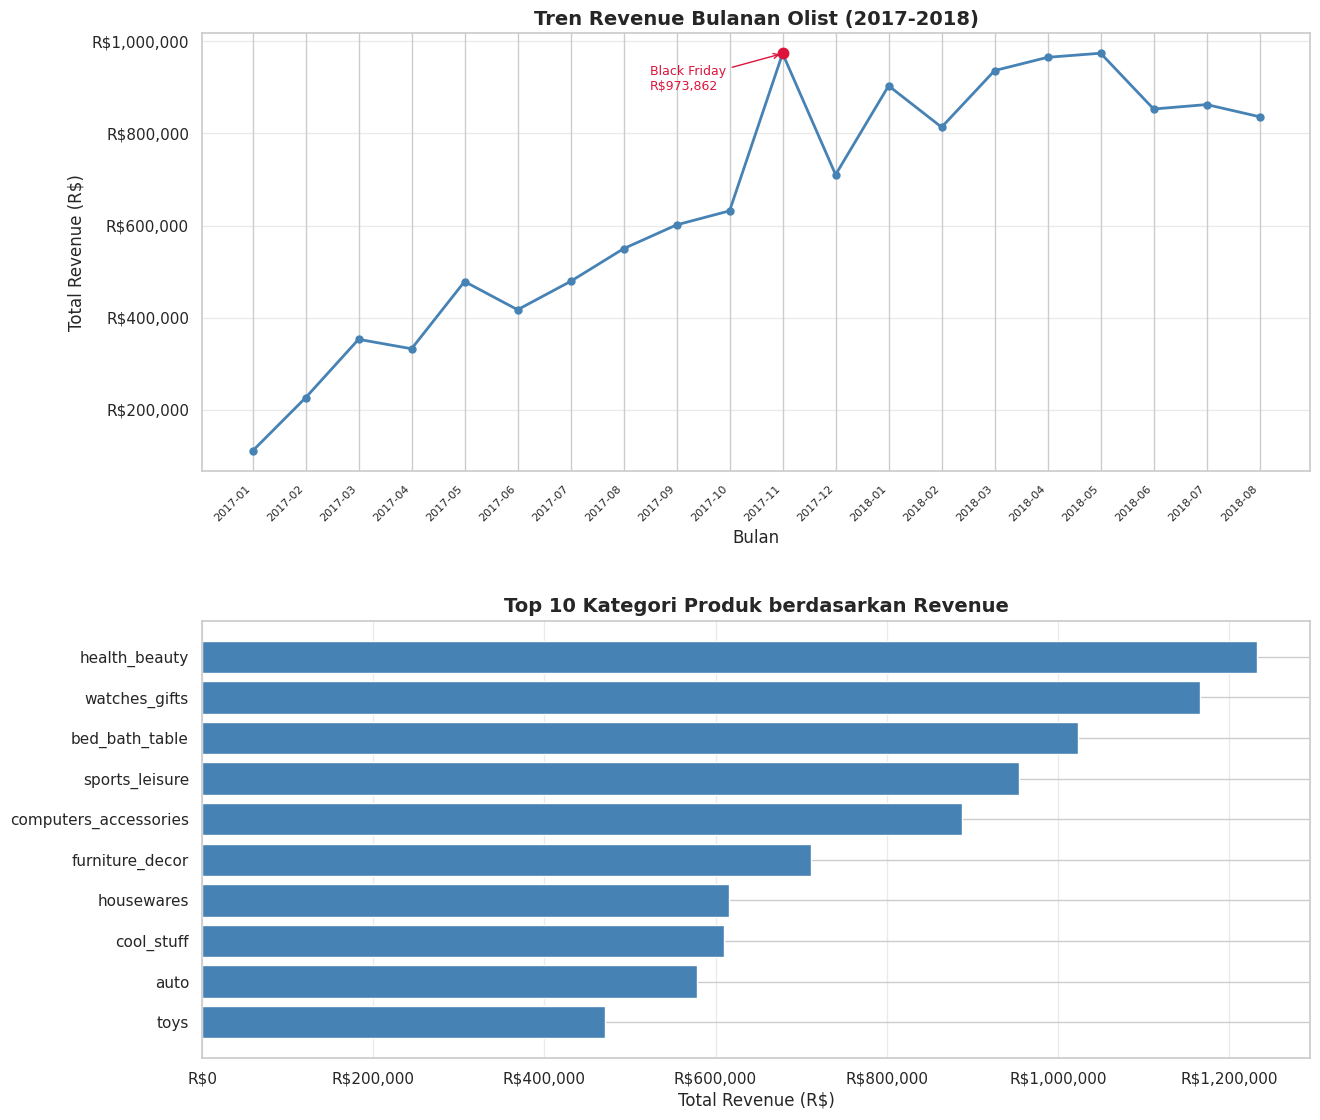

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# --- Q1a: Tren Revenue Bulanan ---
ax1 = axes[0]

x_labels = [str(p) for p in monthly_revenue["year_month"]]
y_values = monthly_revenue["total_revenue"].values

ax1.plot(x_labels, y_values, marker='o', linewidth=2,
         color='steelblue', markersize=5, label="Monthly Revenue")

# Anotasi lonjakan November 2017
nov_idx = x_labels.index("2017-11")
nov_val = y_values[nov_idx]
ax1.plot(x_labels[nov_idx], nov_val, 'o', color='crimson', markersize=7.5, zorder=5)
ax1.annotate(
    f"Black Friday\nR${nov_val:,.0f}",
    xy=(nov_idx, nov_val),
    xytext=(nov_idx - 2.5, nov_val - 80000),
    arrowprops=dict(arrowstyle="->", color="crimson"),
    fontsize=9, color="crimson"
)

ax1.set_title("Tren Revenue Bulanan Olist (2017-2018)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Bulan")
ax1.set_ylabel("Total Revenue (R$)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
ax1.set_xticks(range(len(x_labels)))
ax1.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax1.grid(axis='y', alpha=0.4)

# --- Q1b: Top 10 Kategori by Revenue ---
ax2 = axes[1]

cat_sorted = category_revenue.sort_values("total_revenue", ascending=True)  # ascending=True untuk horizontal bar
colors_cat = ['steelblue'] * len(cat_sorted)

ax2.barh(cat_sorted["product_category_name_english"],
         cat_sorted["total_revenue"], color=colors_cat)
ax2.set_title("Top 10 Kategori Produk berdasarkan Revenue", fontsize=14, fontweight='bold')
ax2.set_xlabel("Total Revenue (R$)")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
ax2.grid(axis='x', alpha=0.4)

plt.tight_layout(pad=3.0)
plt.savefig("q1_revenue.png", dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Grafik menunjukkan pola pertumbuhan yang konsisten. Mulai dari Januari 2018, *revenue* bulanan stabil di atas angka BRL 800.000, yang merupakan peningkatan signifikan dibandingkan rata-rata pencapaian tahun 2017.
- Lonjakan pada November 2017 (BRL 973.861) adalah efek promosi akhir tahun yang bersifat musiman, ditandai dengan penurunan pada bulan Desember. Namun, *revenue* reguler pada Mei 2018 (BRL 974.447) berhasil melampaui angka tertinggi Black Friday 2017 tersebut. Hal ini mengindikasikan adanya peningkatan volume transaksi platform secara keseluruhan.
- Distribusi pendapatan antar kategori teratas terbagi cukup merata. Tiga kategori utama (`health_beauty`, `watches_gifts`, dan `bed_bath_table`) masing-masing mencatat pendapatan di atas BRL 1 juta tanpa adanya dominasi ekstrem terhadap sisa kategori lainnya. Ini menunjukkan bahwa platform memiliki diversifikasi produk yang memadai.

### Pertanyaan 2: Keterlambatan Pengiriman per State

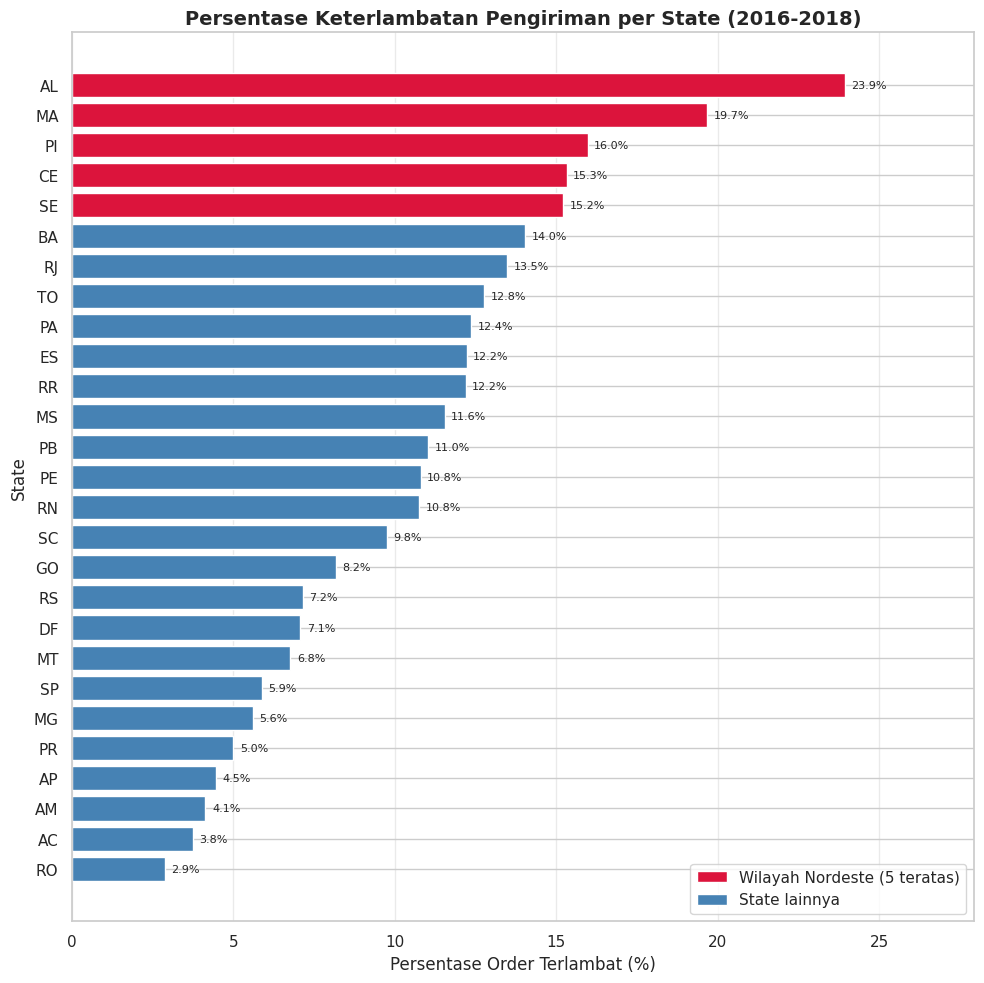

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

# Urutkan dari tertinggi ke terendah, flip untuk horizontal bar
late_sorted = late_by_state.sort_values("late_pct", ascending=True)

# Warna merah untuk 5 state Timur Laut/Nordeste teratas
nordeste_top5 = {"AL", "MA", "PI", "CE", "SE"}
colors_state = [
    "crimson" if state in nordeste_top5 else "steelblue"
    for state in late_sorted["customer_state"]
]

bars = ax.barh(late_sorted["customer_state"], late_sorted["late_pct"],
               color=colors_state)

# Label persentase di ujung bar
for bar, val in zip(bars, late_sorted["late_pct"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va='center', fontsize=8)

# Legend manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='crimson', label='Wilayah Nordeste (5 teratas)'),
    Patch(facecolor='steelblue', label='State lainnya')
]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_title("Persentase Keterlambatan Pengiriman per State (2016-2018)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Persentase Order Terlambat (%)")
ax.set_ylabel("State")
ax.grid(axis='x', alpha=0.4)
ax.set_xlim(0, late_sorted["late_pct"].max() + 4)

plt.tight_layout()
plt.savefig("q2_late_delivery.png", dpi=150, bbox_inches='tight')
plt.show()

**Insight:** (Opsional)
- Visualisasi ini memperjelas adanya kendala logistik yang terpusat di wilayah Timur Laut (Nordeste) Brasil. Posisi teratas pada grafik didominasi oleh negara bagian dari wilayah tersebut (AL, MA, PI, CE, SE, dan BA) yang mencatatkan tingkat keterlambatan secara konsisten di atas 14%.
- Di sisi lain, São Paulo (SP) menempati posisi bawah dengan tingkat keterlambatan hanya 5,89%, meskipun menangani volume pesanan tertinggi secara absolut (40.493 order). Hal ini mengonfirmasi bahwa tingginya jumlah pesanan tidak otomatis menurunkan performa pengiriman, selama wilayah tersebut (seperti SP) didukung oleh infrastruktur logistik yang memadai.

### Pertanyaan 3: Hubungan Ketepatan Pengiriman dan Review Score

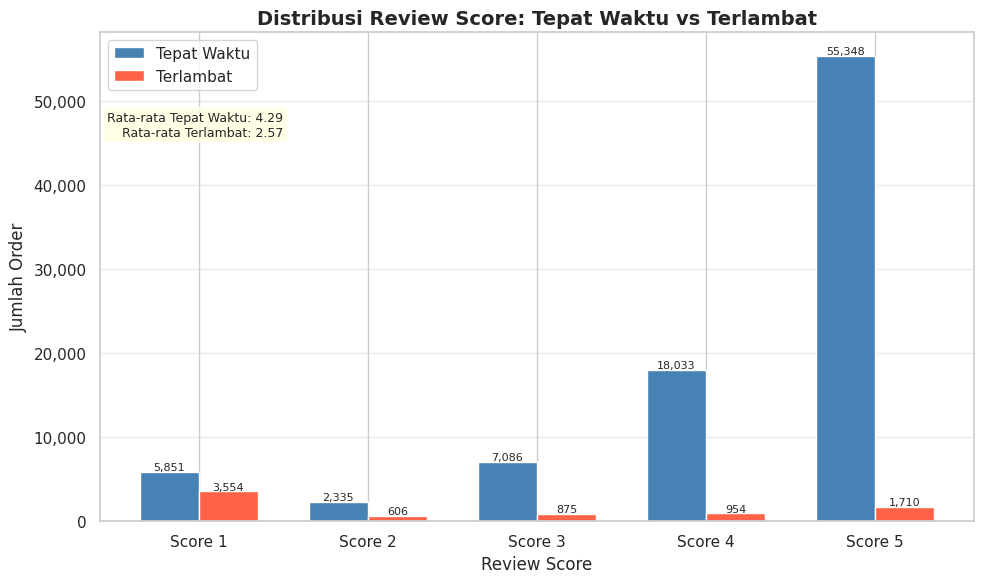

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

scores = [1, 2, 3, 4, 5]
on_time_counts = score_dist[score_dist["is_late"] == "Tepat Waktu"].set_index("review_score")["count"]
late_counts = score_dist[score_dist["is_late"] == "Terlambat"].set_index("review_score")["count"]

x = np.arange(len(scores))
width = 0.35

bars1 = ax.bar(x - width/2,
               [on_time_counts.get(s, 0) for s in scores],
               width, label="Tepat Waktu", color="steelblue")
bars2 = ax.bar(x + width/2,
               [late_counts.get(s, 0) for s in scores],
               width, label="Terlambat", color="tomato")

# Label nilai di atas bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{int(bar.get_height()):,}", ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{int(bar.get_height()):,}", ha='center', fontsize=8)

ax.set_title("Distribusi Review Score: Tepat Waktu vs Terlambat",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Review Score")
ax.set_ylabel("Jumlah Order")
ax.set_xticks(x)
ax.set_xticklabels([f"Score {s}" for s in scores])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
ax.grid(axis='y', alpha=0.4)

# Anotasi rata-rata
ax.text(0.21, 0.84,
        f"Rata-rata Tepat Waktu: 4.29\nRata-rata Terlambat: 2.57",
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8),
        fontsize=9)

plt.tight_layout()
plt.savefig("q3_review_score.png", dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Visualisasi distribusi memperlihatkan pola yang saling bertolak belakang antara kedua kelompok. Ulasan untuk pesanan tepat waktu sangat condong pada nilai sempurna (didominasi skor 5), sedangkan pesanan yang terlambat terpusat pada ulasan paling negatif (didominasi skor 1).
- Perbedaan pola distribusi yang drastis ini mengonfirmasi bahwa keterlambatan pengiriman bukan sekadar mengurangi rata-rata kepuasan, melainkan secara langsung memicu kekecewaan berat dari pelanggan.

### Pertanyaan 4: New vs Repeat Customers

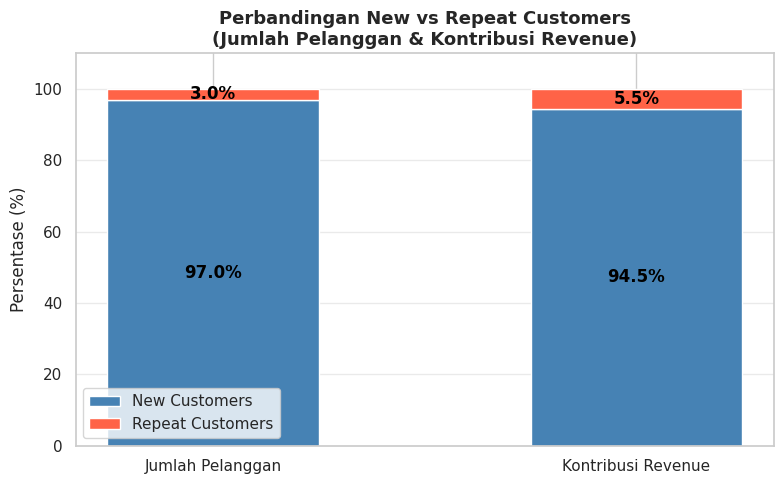

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

categories = ["Jumlah Pelanggan", "Kontribusi Revenue"]
new_pct = [
    type_summary[type_summary["customer_type"] == "New"]["customer_pct"].values[0],
    type_summary[type_summary["customer_type"] == "New"]["revenue_pct"].values[0],
]
repeat_pct = [
    type_summary[type_summary["customer_type"] == "Repeat"]["customer_pct"].values[0],
    type_summary[type_summary["customer_type"] == "Repeat"]["revenue_pct"].values[0],
]

x = np.arange(len(categories))
width = 0.5

bar_new = ax.bar(x, new_pct, width, label="New Customers", color="steelblue")
bar_repeat = ax.bar(x, repeat_pct, width, bottom=new_pct,
                    label="Repeat Customers", color="tomato")

# Label di dalam bar
for i, (n, r) in enumerate(zip(new_pct, repeat_pct)):
    ax.text(i, n / 2, f"{n:.1f}%", ha='center', va='center',
            fontsize=12, fontweight='bold', color='black')
    ax.text(i, n + r / 2, f"{r:.1f}%", ha='center', va='center',
            fontsize=12, fontweight='bold', color='black')

ax.set_title("Perbandingan New vs Repeat Customers\n(Jumlah Pelanggan & Kontribusi Revenue)",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Persentase (%)")
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 110)
ax.legend(loc='lower left')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig("q4_repeat_customers.png", dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Visualisasi proporsi ini menegaskan bahwa persentase *revenue* dari *repeat customers* (5,51%) lebih besar daripada persentase jumlah pelanggan itu sendiri (3%). Hal ini mengonfirmasi secara langsung bahwa pelanggan yang kembali berbelanja memiliki rata-rata nilai transaksi per pengguna yang lebih tinggi dibandingkan pelanggan baru.

## Analisis Lanjutan RFM Analysis

RFM Analysis adalah teknik segmentasi pelanggan berdasarkan tiga dimensi perilaku pembelian:
- **Recency (R):** Seberapa baru pelanggan melakukan transaksi terakhirnya (dalam hari).
- **Frequency (F):** Seberapa sering pelanggan melakukan transaksi dalam periode analisis.
- **Monetary (M):** Seberapa besar total pengeluaran pelanggan dalam periode analisis.

Teknik ini digunakan untuk mengidentifikasi segmen pelanggan bernilai tinggi yang dapat menjadi target program retensi dan loyalitas.

### Hitung Nilai RFM

In [ ]:
# Tentukan tanggal referensi (hari setelah transaksi terakhir di dataset)
reference_date = orders_delivered_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

# Gabungkan data yang dibutuhkan
rfm_base = orders_delivered_df[["order_id", "customer_id", "order_purchase_timestamp"]].merge(
    customers_df[["customer_id", "customer_unique_id"]], on="customer_id"
).merge(
    order_items_df[["order_id", "price"]], on="order_id"
)

# Hitung R, F, M per customer unik
rfm_df = rfm_base.groupby("customer_unique_id").agg(
    Recency=("order_purchase_timestamp", lambda x: (reference_date - x.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("price", "sum")
).reset_index()

print("=== Statistik RFM ===")
print(rfm_df[["Recency", "Frequency", "Monetary"]].describe().round(2))

=== Statistik RFM ===
        Recency  Frequency  Monetary
count  93349.00   93349.00  93349.00
mean     237.95       1.03    141.62
std      152.59       0.21    215.70
min        1.00       1.00      0.85
25%      114.00       1.00     47.65
50%      219.00       1.00     89.70
75%      346.00       1.00    154.69
max      714.00      15.00  13440.00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Scoring dan Segmentasi RFM

In [ ]:
# Buat skor RFM (1-4) menggunakan quartile
rfm_df["R_score"] = pd.qcut(rfm_df["Recency"], q=4, labels=[4, 3, 2, 1])
rfm_df["F_score"] = pd.qcut(rfm_df["Frequency"].rank(method="first"), q=4, labels=[1, 2, 3, 4])
rfm_df["M_score"] = pd.qcut(rfm_df["Monetary"], q=4, labels=[1, 2, 3, 4])

rfm_df["RFM_Score"] = (
    rfm_df["R_score"].astype(str) +
    rfm_df["F_score"].astype(str) +
    rfm_df["M_score"].astype(str)
)

# Segmentasi berdasarkan kombinasi R dan F score
def segment_customer(row):
    r = int(row["R_score"])
    f = int(row["F_score"])
    m = int(row["M_score"])
    if r >= 3 and f >= 3:
        return "Champions"
    elif r >= 3 and f <= 2:
        return "Promising"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2 and m >= 3:
        return "Needs Attention"
    else:
        return "Lost"

rfm_df["Segment"] = rfm_df.apply(segment_customer, axis=1)

segment_summary = (
    rfm_df.groupby("Segment")
    .agg(
        total_customers=("customer_unique_id", "count"),
        avg_recency=("Recency", "mean"),
        avg_frequency=("Frequency", "mean"),
        avg_monetary=("Monetary", "mean"),
        total_revenue=("Monetary", "sum"),
    )
    .round(2)
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

print("=== Ringkasan Segmen RFM ===")
print(segment_summary.to_string(index=False))

=== Ringkasan Segmen RFM ===
        Segment  total_customers  avg_recency  avg_frequency  avg_monetary  total_revenue
      Champions            23489       112.25           1.08        147.06     3454392.49
        At Risk            23185       364.11           1.06        143.03     3316122.66
      Promising            23352       112.06           1.00        137.52     3211393.87
Needs Attention            11363       364.64           1.00        235.28     2673488.46
           Lost            11960       365.67           1.00         47.21      564672.45


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Visualisasi RFM

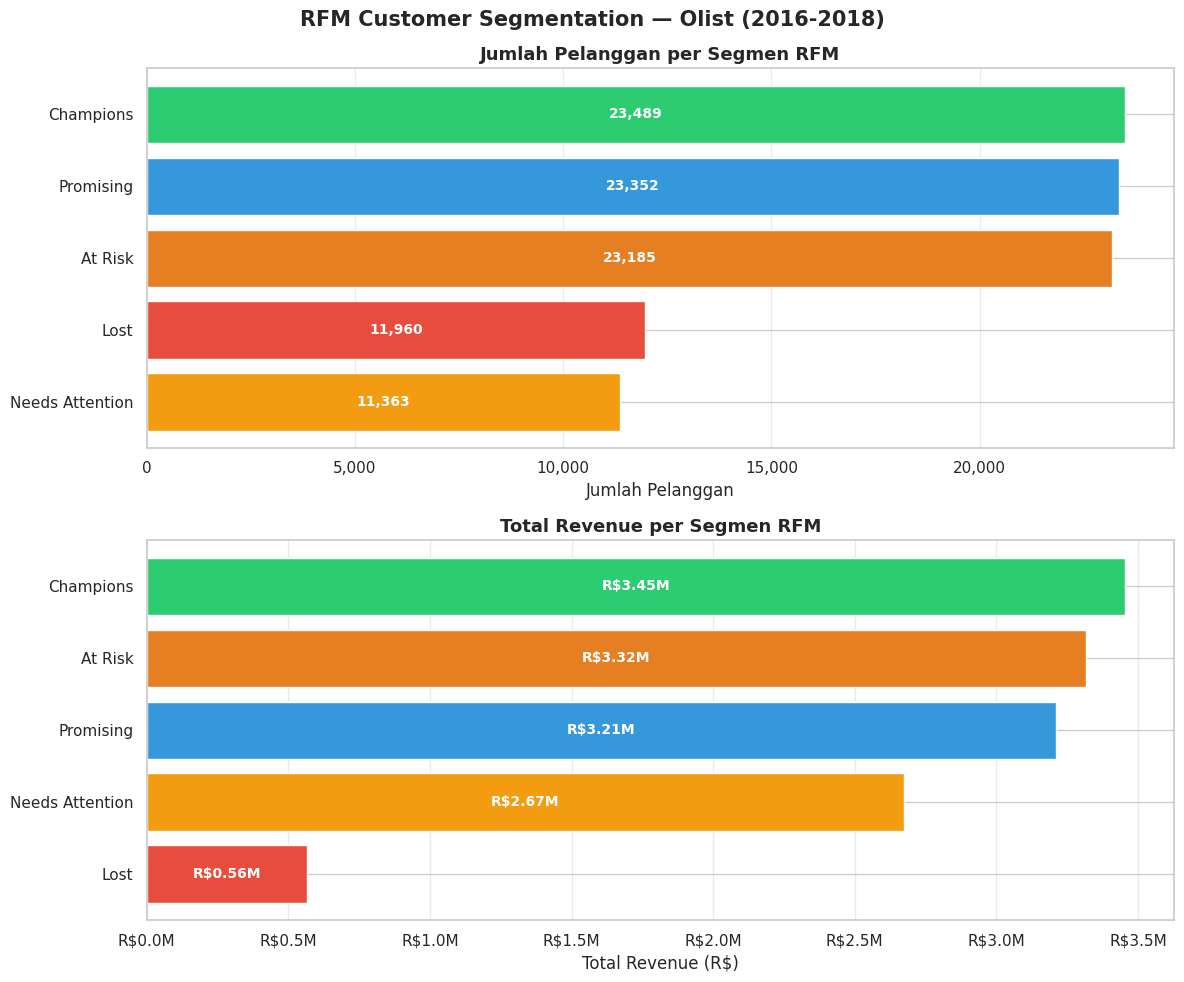

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

segment_colors = {
    "Champions": "#2ecc71",
    "Promising": "#3498db",
    "Needs Attention": "#f39c12",
    "At Risk": "#e67e22",
    "Lost": "#e74c3c",
}

# --- Chart 1: Jumlah Pelanggan per Segmen ---
ax1 = axes[0]
seg_sorted = segment_summary.sort_values("total_customers", ascending=True)
colors1 = [segment_colors[s] for s in seg_sorted["Segment"]]

bars = ax1.barh(seg_sorted["Segment"], seg_sorted["total_customers"], color=colors1)
for bar, val in zip(bars, seg_sorted["total_customers"]):
    ax1.text(
        bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
        f"{int(val):,}", va='center', ha='center',
        fontsize=10, fontweight='bold', color='white'
    )

ax1.set_title("Jumlah Pelanggan per Segmen RFM", fontsize=13, fontweight='bold')
ax1.set_xlabel("Jumlah Pelanggan")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.grid(axis='x', alpha=0.4)

# --- Chart 2: Total Revenue per Segmen ---
ax2 = axes[1]
seg_sorted2 = segment_summary.sort_values("total_revenue", ascending=True)
colors2 = [segment_colors[s] for s in seg_sorted2["Segment"]]

bars2 = ax2.barh(seg_sorted2["Segment"], seg_sorted2["total_revenue"], color=colors2)
for bar, val in zip(bars2, seg_sorted2["total_revenue"]):
    label = f"R${val/1e6:.2f}M"
    ax2.text(
        bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
        label, va='center', ha='center',
        fontsize=10, fontweight='bold', color='white'
    )

ax2.set_title("Total Revenue per Segmen RFM", fontsize=13, fontweight='bold')
ax2.set_xlabel("Total Revenue (R$)")
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x/1e6:.1f}M"))
ax2.grid(axis='x', alpha=0.4)

plt.suptitle("RFM Customer Segmentation — Olist (2016-2018)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("rfm_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

**Insight:**
- Distribusi pelanggan pada tiga segmen utama (Champions, At Risk, dan Promising) terlihat cukup merata di kisaran 23.000 pelanggan. Hal ini mengindikasikan bahwa skema *scoring* RFM yang diterapkan sudah cukup proporsional dalam memetakan basis pelanggan.
- Segmen **Champions** mencatatkan total *revenue* tertinggi (BRL 3,45 juta) dengan rata-rata transaksi terakhir (*recency*) sekitar 112 hari yang lalu. Kelompok ini merupakan aset platform paling berharga yang program loyalitasnya harus terus dijaga.
- Segmen **At Risk** memiliki populasi dan kontribusi *revenue* (BRL 3,31 juta) yang hampir menyamai segmen Champions. Namun, rata-rata *recency* mereka sudah menyentuh 364 hari. Ini menjadikannya segmen paling kritis; mereka adalah mantan pengguna aktif yang perlu segera ditargetkan dengan kampanye *win-back* sebelum benar-benar beralih (*churn*).
- Segmen **Needs Attention** justru mencetak rata-rata nominal pengeluaran (*monetary*) per pengguna tertinggi (BRL 235,28) meskipun frekuensinya rendah. Karakteristik ini menunjukkan bahwa mereka adalah pelanggan *high-value* (berbelanja nominal besar namun jarang) yang sangat potensial untuk direaktivasi.
- Segmen **Lost** diisi oleh pelanggan dengan pengeluaran terkecil (rata-rata BRL 47,21) dan sudah tidak aktif selama sekitar setahun (365 hari). Dari sudut pandang bisnis, biaya akuisisi ulang untuk kelompok ini kemungkinan besar tidak akan sepadan dengan nilai transaksinya (*Lifetime Value*), sehingga lebih baik alokasi dana difokuskan ke segmen lain.

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1:** *Revenue* Olist menunjukkan pertumbuhan yang konsisten sepanjang 2017-2018, dengan rata-rata bulanan 2018 yang secara keseluruhan berada jauh di atas 2017. Lonjakan signifikan terjadi pada November 2017 (BRL 973.861) yang bertepatan dengan periode Black Friday. Kategori `health_beauty` dan `watches_gifts` menjadi kontributor pendapatan tertinggi, mencerminkan preferensi belanja online pelanggan Brasil terhadap produk bernilai menengah yang mudah dikirim.
- **Conclusion Pertanyaan 2:** Keterlambatan pengiriman di Brasil bersifat regional dan sistemik. Lima negara bagian dengan tingkat keterlambatan tertinggi, yaitu AL (23,93%), MA (19,67%), PI (15,97%), CE (15,32%), dan SE (15,22%), seluruhnya berada di wilayah Timur Laut/Nordeste. Hal ini mengindikasikan kelemahan infrastruktur logistik yang terkonsentrasi di kawasan tersebut. Sebaliknya, SP yang memiliki volume order tertinggi justru mencatat keterlambatan terendah (5,89%), membuktikan bahwa kedekatan dengan pusat distribusi berperan penting dalam performa pengiriman.
- **Conclusion Pertanyaan 3:** Terdapat korelasi yang kuat antara ketepatan pengiriman dan kepuasan pelanggan. Order yang tiba tepat waktu mendapatkan rata-rata *review score* 4,29, sementara order yang terlambat anjlok di angka 2,57. Lebih dari itu, keterlambatan secara aktif memicu lonjakan ulasan berskor 1 (3.554 dari 7.699 order terlambat), yang berpotensi merusak reputasi platform secara langsung.
- **Conclusion Pertanyaan 4:** Tingkat *repeat purchase* di Olist sangat rendah (3%), yang sangat wajar jika melihat model bisnis Olist sebagai fasilitator *marketplace*. Karena pelanggan bertransaksi di platform pihak ketiga, *brand awareness* secara langsung ke nama Olist sulit terbentuk. Meski demikian, *repeat customers* terbukti memiliki nilai transaksi rata-rata yang lebih tinggi, dengan kontribusi *revenue* (5,51%) yang melampaui proporsi jumlah pelanggannya. Analisis RFM lebih lanjut mengidentifikasi segmen **At Risk** (23.185 pelanggan, *revenue* BRL 3,31 juta) sebagai kelompok paling kritis yang membutuhkan intervensi segera.

**Rekomendasi Action Item:**
- **Perkuat kategori unggulan di momen puncak.** Mengingat lonjakan Black Friday 2017 yang sangat signifikan dan dominasi kategori `health_beauty` serta `watches_gifts`, Olist dapat memaksimalkan *revenue* dengan memprioritaskan ketersediaan stok, promosi, dan visibilitas kategori-kategori ini menjelang periode belanja besar (seperti Black Friday, Natal, dan Hari Valentine).
- **Tingkatkan infrastruktur logistik di wilayah Nordeste.** Lima negara bagian Timur Laut/Nordeste secara konsisten mencatat keterlambatan tertinggi. Olist perlu bernegosiasi dengan mitra logistik untuk membuka *hub* distribusi regional di kota-kota besar area tersebut, seperti Fortaleza (CE) atau Salvador (BA), guna memangkas jarak dan waktu pengiriman secara sistemik.
- **Jadikan ketepatan pengiriman sebagai KPI utama penjual.** Mengingat korelasi kuat antara keterlambatan dan *review score* yang rendah, Olist sebaiknya menerapkan sistem penalti atau insentif bagi *seller* berdasarkan performa pengiriman mereka. Hal ini penting untuk mendorong ekosistem yang lebih bertanggung jawab (*accountable*) terhadap kepuasan pelanggan akhir.
- **Luncurkan kampanye *win-back* untuk segmen At Risk.** Segmen ini menyimpan potensi *revenue* historis sebesar BRL 3,31 juta dari pelanggan yang sudah hampir satu tahun tidak aktif. Program reaktivasi berupa *voucher* eksklusif atau notifikasi personal yang dikirimkan sebelum mereka melewati batas ketidakaktifan satu tahun dapat menjadi langkah retensi pertama yang efisien dan terukur.

## Ekspor Data untuk Dashboard

In [ ]:
import os
os.makedirs("dashboard", exist_ok=True)

# Gabungkan semua data yang dibutuhkan dashboard
main_data = orders_delivered_df[["order_id", "customer_id", "order_purchase_timestamp",
                                  "order_delivered_customer_date",
                                  "order_estimated_delivery_date"]].merge(
    customers_df[["customer_id", "customer_unique_id", "customer_state"]], on="customer_id"
).merge(
    order_items_df[["order_id", "product_id", "price", "freight_value"]], on="order_id"
).merge(
    products_clean_df[["product_id", "product_category_name_english"]], on="product_id"
).merge(
    reviews_df[["order_id", "review_score"]], on="order_id", how="left"
)

# Tambahkan kolom turunan
main_data["is_late"] = (
    main_data["order_delivered_customer_date"] >
    main_data["order_estimated_delivery_date"]
).astype(int)

main_data["year_month"] = main_data["order_purchase_timestamp"].dt.to_period("M").astype(str)

# Tambahkan data RFM
main_data = main_data.merge(
    rfm_df[["customer_unique_id", "Recency", "Frequency", "Monetary", "Segment"]],
    on="customer_unique_id",
    how="left"
)

print(f"main_data siap: {main_data.shape}")
print(main_data.head(3).to_string())

# Export
main_data.to_csv("dashboard/main_data.csv", index=False)
print("\nTersimpan ke dashboard/main_data.csv")

main_data siap: (109286, 18)
                           order_id                       customer_id order_purchase_timestamp order_delivered_customer_date order_estimated_delivery_date                customer_unique_id customer_state                        product_id   price  freight_value product_category_name_english  review_score  is_late year_month  Recency  Frequency  Monetary    Segment
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d      2017-10-02 10:56:33           2017-10-10 21:25:13                    2017-10-18  7c396fd4830fd04220f754e42b4e5bff             SP  87285b34884572647811a353c7ac498a   29.99           8.72                    housewares           4.0        0    2017-10      332          2     65.38    At Risk
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef      2018-07-24 20:41:37           2018-08-07 15:27:45                    2018-08-13  af07308b275d755c9edb36a90c618231             BA  595fac2a385ac33a80bd5114aec74eb8  

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Tersimpan ke dashboard/main_data.csv
